# Quickstart (30 minutes)

Goal: take a fresh checkout of PREP-SHOT, solve the shipped example, read the results, change one input, and re-solve -- all in about half an hour. No prior knowledge of capacity-expansion modeling is assumed; everything happens against the `input/` folder that comes with the repo.

If anything in this page does not work for you, please open a [GitHub issue](https://github.com/PREP-NexT/PREP-SHOT/issues) -- we read every report and a broken Quickstart is the bug we most want to know about.

## Step 1 -- Install (5 minutes)

PREP-SHOT requires Python 3.9 or newer. Conda is recommended so the optimization-solver dependencies stay isolated:

```bash
conda create -n prep-shot python=3.11 -y
conda activate prep-shot

git clone https://github.com/PREP-NexT/PREP-SHOT.git
cd PREP-SHOT
pip install -e .
```

The default solver is the open-source [HiGHS](https://highs.dev/), installed automatically as a wheel. To use a commercial solver (Gurobi, COPT, MOSEK) instead, set `solver` in `config.json` -- see the [Model Inputs/Outputs page](Model_input_output.rst).

## Step 2 -- Solve the shipped example (5 minutes)

The repo ships a self-contained 3-zone, 11-year example in `input/`. We solve it programmatically so this notebook works regardless of the working directory.

In [1]:
import sys
import io
import pathlib

# Notebooks inherit the kernel launcher's argv; clear it so
# prepshot.set_up.parse_cli_arguments() sees no scenario flags.
sys.argv = ['notebook']

# Locate the repo root (the dir containing run.py and config.json).
# This makes the notebook portable: it works from doc/source/, from
# the repo root, or from any subdirectory of a checkout.
repo_root = pathlib.Path.cwd()
while not (repo_root / 'run.py').exists():
    if repo_root == repo_root.parent:
        raise RuntimeError(
            'Could not find PREP-SHOT repo root; run this notebook '
            'from inside a checkout of PREP-NexT/PREP-SHOT.'
        )
    repo_root = repo_root.parent
print(f'PREP-SHOT repo root: {repo_root}')


PREP-SHOT repo root: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT


In [2]:
import os
import sys
import tempfile
from prepshot.cli import main

# HiGHS writes its progress log via C-level stdout (file
# descriptor 1), which bypasses Python's sys.stdout. Redirect
# the file descriptor to a tempfile during the solve so the
# notebook output stays readable; we keep a path to the log so
# the next cell can extract the final objective.
with tempfile.NamedTemporaryFile('w+', delete=False, prefix='prepshot_solve_') as f:
    log_path = f.name
    sys.stdout.flush()
    saved_fd = os.dup(1)
    os.dup2(f.fileno(), 1)
    try:
        solved = main(root_dir=str(repo_root))
    finally:
        sys.stdout.flush()
        os.dup2(saved_fd, 1)
        os.close(saved_fd)
print(f'log: {log_path}')


2026-05-03 19:18:30 INFO: Set parameter solver to value highs


2026-05-03 19:18:30 INFO: Set parameter input folder to value input


2026-05-03 19:18:30 INFO: Set parameter output_filename to value year.nc


2026-05-03 19:18:30 INFO: Set parameter time_length to value 48


2026-05-03 19:18:30 INFO: Start running 'create_model'


...

2026-05-03 19:20:21 INFO: Results are written to ./output/year.nc


2026-05-03 19:20:21 INFO: Start running 'save_to_excel'


2026-05-03 19:20:25 INFO: Finished 'save_to_excel' in 4.43 seds


2026-05-03 19:20:25 INFO: Results are written to separate excel files


log: /var/folders/y_/ypyrt83d1hl9fhjtt_ftpwg00000gn/T/prepshot_solve_1j_icnsv


In [3]:
# Pick out the final objective value from the captured log.
with open(log_path) as f:
    log = f.read()
objective_lines = [l for l in log.splitlines() if 'Objective value' in l]
if objective_lines:
    # The solve runs `iteration_number` head iterations; each
    # prints an objective. The last one is what matters.
    print(objective_lines[-1].strip())
print(f'Solved: {solved}')


Objective value     :  1.8805577710e+11
Solved: True


On commodity hardware the default settings (48 hours, 1 representative month, 3 head iterations) finish in around 2 minutes. The solver log will report `Objective value : 1.8809...e+11`, and a NetCDF file appears under `output/`. Everything in the rest of this notebook reads from that file.

The log lines `Water head error: ...` and the warning `Failed to converge. Maximum iteration exceeded.` are normal for the default settings: PREP-SHOT runs three head-iteration rounds and reports the final residual. Bump `iteration_number` in `config.json` if you want a tighter (slower) converged solve.

## Step 3 -- Open the results (10 minutes)

PREP-SHOT writes results in [xarray](https://docs.xarray.dev)'s NetCDF format, so any tool that reads NetCDF can consume them.

In [4]:
import xarray as xr
import json

config = json.loads((repo_root / 'config.json').read_text())
# config stores the filename WITHOUT extension; the model writes
# both .nc (xarray) and .xlsx alongside each other.
output_path = (
    repo_root
    / 'output'
    / (config['general_parameters']['output_filename'] + '.nc')
)
print(f'Reading results from: {output_path}')

ds = xr.open_dataset(output_path)
print(sorted(ds.data_vars))


Reading results from: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/output/year.nc
['carbon', 'carbon_breakdown', 'charge', 'cost', 'cost_fix', 'cost_fix_breakdown', 'cost_newline', 'cost_newline_breakdown', 'cost_newtech', 'cost_newtech_breakdown', 'cost_var', 'cost_var_breakdown', 'gen', 'genflow', 'income', 'install', 'public_debt_newtech', 'shadow_price_demand', 'spillflow', 'trans_export']


Three things worth a first look:

**1. Total cost.** A single number, the NPV of system cost over the planning horizon.

In [5]:
print(f"Total cost: ${float(ds.cost):,.0f}")

Total cost: $188,055,777,096


**2. Installed capacity over time.** Which technologies expanded, in which zones, and when.

In [6]:
install_by_year = ds["install"].sum("zone").to_pandas()
install_by_year

tech,Coal,Solar,Wind,Storage,Grand_Coulee,Chief_Joseph,Wells,Rocky_Reach,Rock_Island,Wanapum,Priest_Rapids,Lower_Granite,Little_Goose,Lower_Monumental,Ice_Harbor,McNary,John_Day,The_Dalles,Bonneville
year,,,,,,,,,,,,,,,,,,,
2020,34.526238,0.000000,28045.085013,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2021,34.526238,0.000000,28045.085013,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2022,34.526238,0.000000,28045.085013,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2023,34.526238,0.000000,28045.085013,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2024,34.526238,19246.734302,28045.085013,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2025,34.526238,19246.734302,28045.085013,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2026,34.526238,26519.619727,29965.811926,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2027,34.526238,26519.619727,29965.811926,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2028,34.526238,26519.619727,29965.811926,0.0,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0


**3. Locational marginal prices (shadow prices on demand).** This is the dual of the power-balance constraint -- the marginal cost of one extra MWh of demand at each `(hour, month, year, zone)`. Useful for diagnosing where the system is most stressed.

In [7]:
# LMP at zone BA1 in 2025, averaged over the modeled month:
lmp = ds["shadow_price_demand"].sel(zone="BA1", year=2025).mean("month")
print(lmp)

<xarray.DataArray 'shadow_price_demand' (hour: 48)> Size: 384B
array([0.00000000e+00, 0.00000000e+00, 1.68494800e-13, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 7.81236838e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 8.08277773e-13, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])
Coordinates:
  * hour     (hour) int64 384B 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 

Values in `shadow_price_demand` are **NPV-discounted** dollars per MWh. To recover undiscounted real-year prices, divide by the year's variable-cost factor (computed in `prepshot.load_data.compute_cost_factors`).

A minimal generation-mix chart:

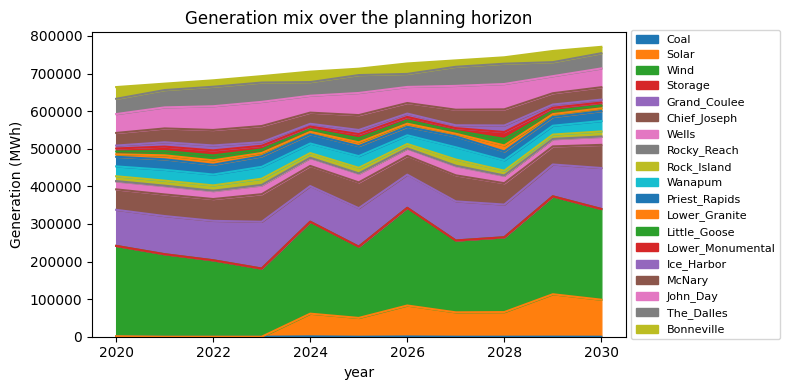

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

gen_by_tech = (
    ds["gen"]
    .sum(["hour", "month", "zone"])  # sum over time and space
    .to_pandas()                     # rows=year, cols=tech
    .clip(lower=0)                   # storage net-discharge can be ~0; clamp
)
# Drop techs that never generate (e.g. storage round-trips to ~0):
gen_by_tech = gen_by_tech.loc[:, gen_by_tech.sum() > 0]

fig, ax = plt.subplots(figsize=(8, 4))
gen_by_tech.plot.area(ax=ax)
ax.set_ylabel("Generation (MWh)")
ax.set_title("Generation mix over the planning horizon")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.tight_layout()
plt.show()


## Step 4 -- Change one input and re-solve (5 minutes)

Every input is a CSV under `input/`. To see how the model responds to a change, try one of these single-file edits.

**Option A -- bump demand 20% in one zone.** Open `input/demand.csv` (long format: `zone, year, month, hour, unit, value`) and multiply the BA1 column by 1.2 in your editor of choice. Then run `python run.py` again. The objective will rise -- the model has to build more capacity or import more from neighboring zones to serve the extra load. `shadow_price_demand` at BA1 should also increase in the most constrained hours.

**Option B -- introduce a carbon tax.** Open `input/policy_carbon_tax.csv` and replace the `value` column with a non-zero number (e.g. `50` USD/tonneCO2). Re-run; the generation mix should shift away from coal and gas toward zero-carbon technologies, raising `cost_carbon` in the breakdown.

**Tip -- run scenarios without overwriting your baseline.** Save your modified file as `input/demand_high.csv` and run `python run.py --demand=high`. PREP-SHOT appends the suffix to the file name, so the baseline `demand.csv` is left untouched. Output goes to `output/year_high.nc`.

## Step 5 -- Where to next

- [Model Inputs/Outputs](Model_input_output.rst) -- full input / output reference, including optional carbon-market and finance modules.
- [Tutorial](Tutorial.rst) -- the same shipped example, with more context on the modeled scenario (3 balancing authorities, 15 hydropower stations, 2020-2030 zero-carbon pathway).
- [Mathematical Notation](Mathematical_notations.rst) -- the underlying linear program.
- [Changelog](Changelog.rst) -- what's new in each release.

If you used PREP-SHOT in published work, please cite it -- see the [Citation Guide](Citations.rst). And if you ran into something rough, the fastest fix is to file an issue on [GitHub](https://github.com/PREP-NexT/PREP-SHOT/issues).